In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [ ]:
df["TotalCharges"].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [ ]:
categorical_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,1.000000


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [ ]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,0.265370,...,0.290217,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,0.441561,...,0.453895,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,1.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,11
Churn,0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

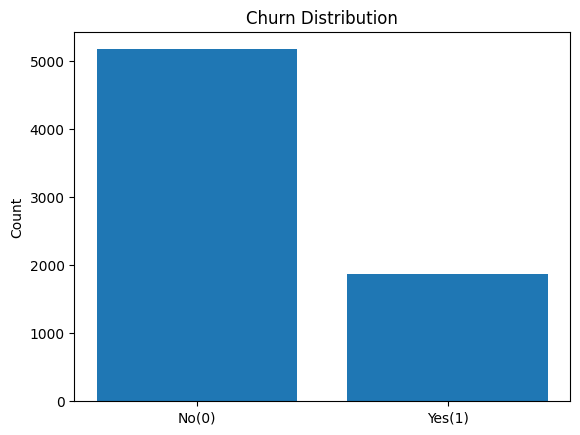

In [ ]:
# Churn Distribution

counts = df['Churn'].value_counts().sort_index()
plt.figure()
plt.bar(['No(0)', 'Yes(1)'], counts.values)
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

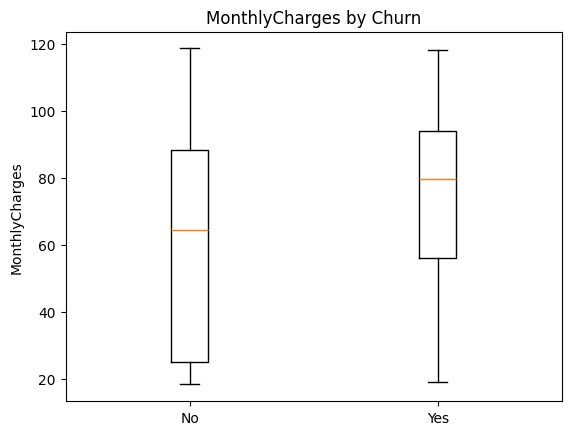

In [ ]:
# Monthly Charges by Churn boxplot

data = [df.loc[df['Churn']==0, 'MonthlyCharges'].dropna(),
        df.loc[df['Churn']==1, 'MonthlyCharges'].dropna()]

plt.figure()
plt.boxplot(data, labels=['No', 'Yes'])
plt.title('MonthlyCharges by Churn')
plt.ylabel('MonthlyCharges')
plt.show()

In [ ]:
# TotalCharges dropped, 'tenure' and 'MonthlyCharges' remains
df = df.drop("TotalCharges", axis=1)

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
# train - test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic = LogisticRegression(max_iter = 2000, class_weight="balanced")
logistic.fit(X_train_scaled, y_train)
y_pred = logistic.predict(X_test_scaled)

In [ ]:
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Logistic Regression evaluation

score = accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.7562707051585423
              precision    recall  f1-score   support

           0       0.74      0.90      0.82      1265
           1       0.79      0.54      0.64       848

    accuracy                           0.76      2113
   macro avg       0.77      0.72      0.73      2113
weighted avg       0.76      0.76      0.75      2113

confusion matrix: 
 [[1142  123]
 [ 392  456]]


ROC-AUC: 0.8401539767571208


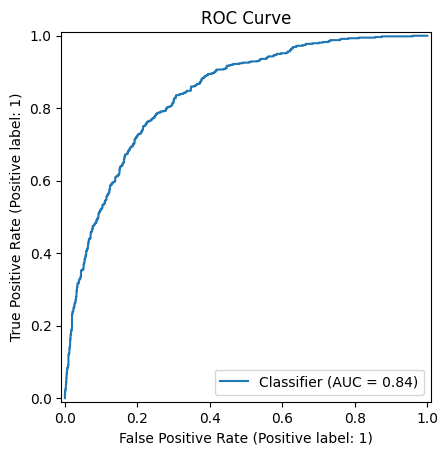

In [ ]:
# ROC curve for Logistic Regression

from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_prob = logistic.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve')
plt.show()

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators = 10, random_state = 15)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=15)

In [ ]:
y_pred = rfc.predict(X_test)

In [ ]:
# Random Forest Evaluation

score = accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.7799337434926644
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1729
           1       0.43      0.65      0.52       384

    accuracy                           0.78      2113
   macro avg       0.67      0.73      0.69      2113
weighted avg       0.82      0.78      0.80      2113

confusion matrix: 
 [[1399  330]
 [ 135  249]]


In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
y_pred = gb.predict(X_test)

In [ ]:
# Gradient Boosting Evaluation

score = accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.795551348793185
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1678
           1       0.50      0.67      0.57       435

    accuracy                           0.80      2113
   macro avg       0.70      0.75      0.72      2113
weighted avg       0.82      0.80      0.81      2113

confusion matrix: 
 [[1390  288]
 [ 144  291]]


In [ ]:
# hyperparameter tuning for Gradient Boosting

from sklearn.model_selection import GridSearchCV

parameters = {
    "loss" :  ["log_loss", "exponential"],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 150, 180, 200],
    "max_depth" : [3,4,5],
    "subsample" : [0.8, 1.0]
}

In [ ]:
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid = parameters, cv = 5, n_jobs = -1, verbose = 1)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 150, 180, 200],
                         'subsample': [0.8, 1.0]},
             verbose=1)

In [ ]:
grid_search.best_params_

{'learning_rate': 0.05,
 'loss': 'log_loss',
 'max_depth': 3,
 'n_estimators': 180,
 'subsample': 0.8}

In [ ]:
y_pred = grid_search.predict(X_test)
print("classification_report: ", classification_report(y_pred, y_test))
print("confusion_matrix: ", confusion_matrix(y_pred, y_test))

classification_report:                precision    recall  f1-score   support

           0       0.91      0.83      0.87      1675
           1       0.51      0.67      0.58       438

    accuracy                           0.80      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.82      0.80      0.81      2113

confusion_matrix:  [[1390  285]
 [ 144  294]]


In [ ]:
# trying other classification models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_classifier(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "K Neighbors Classifier": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Adaboost Classifier": AdaBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    "XGBoost Classifier": XGBClassifier(eval_metric="logloss", random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", class_weight="balanced", random_state=42)
}

for i in range(len(list(models))):
    name = list(models.keys())[i]
    model = list(models.values())[i]

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)


    if y_train_pred.dtype.kind in "fc":
        y_train_pred = (y_train_pred >= 0.5).astype(int)
    if y_test_pred.dtype.kind in "fc":
        y_test_pred = (y_test_pred >= 0.5).astype(int)

    train_acc, train_prec, train_rec, train_f1 = evaluate_classifier(y_train, y_train_pred)
    test_acc,  test_prec,  test_rec,  test_f1  = evaluate_classifier(y_test,  y_test_pred)

    print(name)
    print("Model Performance for training set")
    print("Accuracy : ", train_acc)
    print("Precision: ", train_prec)
    print("Recall   : ", train_rec)
    print("F1 Score : ", train_f1)

    print("------------------------------------------------")

    print("Model Performance for test set")
    print("Accuracy : ", test_acc)
    print("Precision: ", test_prec)
    print("Recall   : ", test_rec)
    print("F1 Score : ", test_f1)

    print("------------------------------------------------\n")

K Neighbors Classifier
Model Performance for training set
Accuracy :  0.8273833671399594
Precision:  0.7092469018112488
Recall   :  0.5767441860465117
F1 Score :  0.6361693031209918
------------------------------------------------
Model Performance for test set
Accuracy :  0.7690487458589683
Precision:  0.599128540305011
Recall   :  0.4749568221070812
F1 Score :  0.5298651252408478
------------------------------------------------

Decision Tree Classifier
Model Performance for training set
Accuracy :  0.7523326572008113
Precision:  0.5162966461974492
Recall   :  0.8472868217054264
F1 Score :  0.6416201937188142
------------------------------------------------
Model Performance for test set
Accuracy :  0.73450070989115
Precision:  0.5100671140939598
Recall   :  0.7875647668393783
F1 Score :  0.6191446028513238
------------------------------------------------

Adaboost Classifier
Model Performance for training set
Accuracy :  0.7912778904665314
Precision:  0.7010785824345146
Recall   :  

In [ ]:
# Training Decision Tree Classifier for final evaluation

dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

y_test_pred = dt.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)


print("Classification Report - Decision Tree Classifier\n")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Churn", "Churn"]
))

Confusion Matrix:
 [[1096  438]
 [ 123  456]]
Classification Report - Decision Tree Classifier

              precision    recall  f1-score   support

   Not Churn       0.90      0.71      0.80      1534
       Churn       0.51      0.79      0.62       579

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.79      0.73      0.75      2113



In [ ]:
from xgboost import XGBClassifier
import pickle

# Train final XGBoost model
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

# Save model
pickle.dump(xgb_model, open("churn_model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Files saved successfully!")

Files saved successfully!


In [ ]:
print(X_train.shape)

(4930, 29)


In [ ]:
print(X_train.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [ ]:
import pickle

pickle.dump(X_train.columns.tolist(), open("columns.pkl", "wb"))